# Assignment 2 Notebook

# VAE model (Merscope)

In [55]:
import scanpy as sc

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/after_label_transfer_manual.h5ad")

In [56]:
import scanpy as sc

pdata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/Plaques_Object.h5ad")

In [57]:
import os
import pandas as pd

data_info = [
    {
        "path": "/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/WT-5xFAD10518pHip300GP/region_0.h5ad",
        "sample_id": "WT1",
        "genotype": "WT",
        "strain": "C57BL6",
        "sex": "Female",
        "age": "12.0 months",
        "region_location": "Posterior Hippocampus",
        "region_short": "pHip",
        "trem2_mutation": False
    },
    {
        "path": "/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/WT-5xFAD10518pHip300GP/region_1.h5ad",
        "sample_id": "5xFAD1",
        "genotype": "5xFAD",
        "strain": "5xFAD (C57BL6 background)",
        "sex": "Female",
        "age": "12.0 months",
        "region_location": "Posterior Hippocampus",
        "region_short": "pHip",
        "trem2_mutation": False
    },
    {
        "path": "/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/5xFAD-TREM2-AnteHip-300x05/region_1.h5ad",
        "sample_id": "WT3",
        "genotype": "WT",
        "strain": "C57BL6",
        "sex": "Male",
        "age": "12.0 months",
        "region_location": "Anterior Hippocampus",
        "region_short": "AnteHip",
        "trem2_mutation": False
    },
    {
        "path": "/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/5xFAD-TREM2-AnteHip-300x05/region_3.h5ad",
        "sample_id": "5xFAD3",
        "genotype": "5xFAD",
        "strain": "5xFAD (C57BL6 background)",
        "sex": "Male",
        "age": "12.0 months",
        "region_location": "Anterior Hippocampus",
        "region_short": "AnteHip",
        "trem2_mutation": False
    }]

data_info_df = pd.DataFrame(data_info)

def make_key(path):
    path = path.replace("\\", "/")
    
    if "WT-5xFAD10518pHip300GP" in path:
        sample = "WT-5xFAD10518pHip300GP"
    elif "5xFAD-TREM2-AnteHip-300x05" in path:
        sample = "5xFAD-TREM2-AnteHip-300x05"
    else:
        return None
    
    region = path.split("region_")[1].split(".")[0].split("/")[0]
    
    return f"{sample}_region_{region}"


data_info_df["key"] = data_info_df["path"].apply(make_key)

pdata.obs["key"] = pdata.obs["sample"].apply(make_key)

sample_id_map = dict(
    zip(
        data_info_df["key"],
        data_info_df["sample_id"]
    )
)

pdata.obs["sample_id"] = pdata.obs["key"].map(sample_id_map)

pdata = pdata[pdata.obs["sample_id"].notna()].copy()

In [58]:
pdata.obsm["spatial"] = pdata.obsm["spatial"][:, [1,0]]

pdata.obs["imagecol"], pdata.obs["imagerow"] = (
    pdata.obs["imagerow"].copy(),
    pdata.obs["imagecol"].copy())

In [59]:
print(pdata)
print(adata)

AnnData object with n_obs × n_vars = 1235 × 300
    obs: 'sample', 'imagecol', 'imagerow', 'fov', 'volume', 'cell_cov', 'batch', 'counts', 'ratio', 'coarse_gen', 'coarse_batch', 'region_labels', 'gen', 'plaque_1', 'region_labels_coarse', 'gen_old', 'key', 'sample_id'
    var: 'mean', 'std'
    uns: 'gen_colors', 'region_labels_colors', 'spatial'
    obsm: 'spatial'
    layers: 'Log_Normalized_Counts', 'Normalized_Counts'
AnnData object with n_obs × n_vars = 136456 × 300
    obs: 'fov', 'center_x', 'center_y', 'x_min', 'x_max', 'y_min', 'y_max', 'volume', 'sample_id', 'genotype', 'strain', 'sex', 'age', 'region_location', 'region_short', 'trem2_mutation', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_300_genes', '_scvi_batch', '_scvi_labels

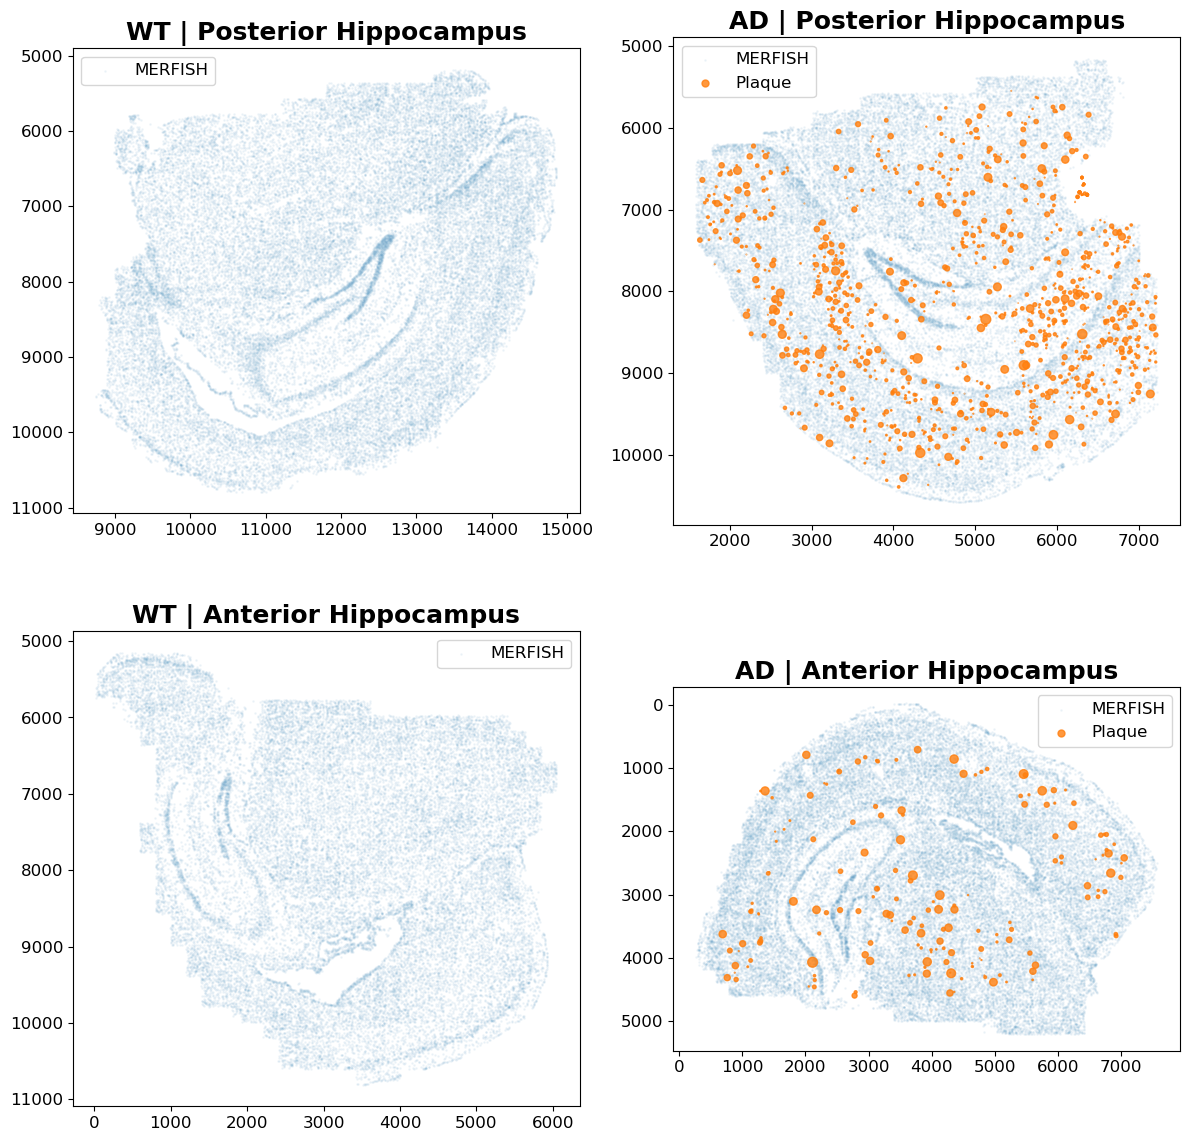

In [62]:
import matplotlib.pyplot as plt
import numpy as np

sample_info = {
    x["sample_id"]: x for x in data_info
}

sample_ids = [
    "WT1",
    "5xFAD1",
    "WT3",
    "5xFAD3"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, sid in zip(axes, sample_ids):

    ad = adata[adata.obs["sample_id"] == sid]
    pd = pdata[pdata.obs["sample_id"] == sid]

    info = sample_info[sid]

    disease = "WT" if info["genotype"] == "WT" else "AD"
    region = info["region_location"]

    ax.scatter(
        ad.obs["center_x"],
        ad.obs["center_y"],
        s=1,
        alpha=0.05,
        label="MERFISH"
    )

    if pd.n_obs > 0:

        volume = pd.obs["volume"].values

        if volume.max() != volume.min():
            size = (
                (volume - volume.min()) /
                (volume.max() - volume.min())
            ) * 50
        else:
            size = np.ones_like(volume) * 20

        ax.scatter(
            pd.obsm["spatial"][:, 0],
            pd.obsm["spatial"][:, 1],
            s=size,
            alpha=0.8,
            label="Plaque"
        )

    ax.set_title(
        f"{disease} | {region}",
        fontsize=18,
        fontweight="bold"
    )

    ax.tick_params(
        labelsize=12
    )

    ax.invert_yaxis()
    ax.set_aspect("equal")

    ax.legend(
        fontsize=12
    )

plt.tight_layout()
plt.show()

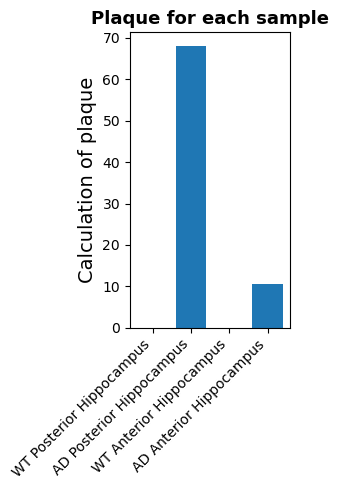

In [80]:
import matplotlib.pyplot as plt

plot_df = burden_df.copy()

plot_df["status"] = plot_df["genotype"].replace(
    {
        "5xFAD": "AD",
        "WT": "WT"
    }
)

plot_df["group"] = (
    plot_df["status"]
    + " "
    + plot_df["region_location"]
)

plt.figure(figsize=(3,5))

plt.bar(
    plot_df["group"],
    plot_df["plaque_volume_per_cell"]
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10,

)

plt.ylabel(
    "Calculation of plaque",
    fontsize=14
)

plt.xlabel(
    "",
    fontsize=14
)

plt.title(
    "Plaque for each sample",    fontweight="bold",
    fontsize=13
)

plt.tight_layout()
plt.show()

In [82]:
adata.obs

,fov,center_x,center_y,x_min,x_max,y_min,y_max,volume,sample_id,genotype,...,cluster_score,final_label_transfer,leiden_res_0.50,leiden_res_0.75,leiden_res_1.00,leiden_res_1.25,leiden_res_0.10,leiden_res_0.25,Mannual_annotaion,mannual_annotaion
WT1_cell_in_reg_0_2_Z_0_fov_4_1254955,4.0,8775.994551,9489.482154,8773.942551,8778.046551,9488.240154,9490.724154,7.645752,WT1,WT,...,1.000000,28 Astro-Epen,0,0,0,0,0,0,Astrocyte,Astrocyte
WT1_cell_in_reg_0_3_Z_0_fov_4_3395225,4.0,8746.564551,9521.612154,8744.350551,8748.778551,9519.344154,9523.880154,15.064056,WT1,WT,...,0.951385,29 Oligo,1,1,1,1,1,1,OPC,Oligodendrocyte
WT1_cell_in_reg_0_4_Z_0_fov_4_8963533,4.0,8746.834551,9525.932154,8744.458551,8749.210551,9523.340154,9528.524154,18.475776,WT1,WT,...,1.000000,32 Immune,2,2,2,2,2,2,Microglia,Microglia
WT1_cell_in_reg_0_6_Z_0_fov_5_2675372,5.0,8981.193719,9618.001006,8976.981719,8985.405719,9614.275006,9621.727006,115.963488,WT1,WT,...,0.549649,01 IT-ET Glut,3,3,3,3,3,3,Glutamatergic_neuron,Glutamatergic_neuron
WT1_cell_in_reg_0_7_Z_0_fov_5_7937334,5.0,8987.241719,9624.805006,8983.245719,8989.833719,9620.755006,9631.447006,332.336520,WT1,WT,...,0.803690,31 Vascular,4,4,4,4,4,4,Endothelial,Endothelial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5xFAD3_cell_in_reg_0_28_Z_0_fov_1908_2795782,1908.0,7552.841932,2578.416383,7548.467932,7557.215932,2573.556383,2581.980383,212.777604,5xFAD3,5xFAD,...,0.550078,31 Vascular,8,8,8,9,4,6,Pericyte,Pericyte
5xFAD3_cell_in_reg_0_29_Z_0_fov_1908_1258497,1908.0,7503.809932,2587.812383,7499.219932,7507.643932,2582.196383,2592.348383,687.872736,5xFAD3,5xFAD,...,0.900162,29 Oligo,9,9,9,11,6,7,Oligodendrocyte,Oligodendrocyte
5xFAD3_cell_in_reg_0_30_Z_0_fov_1908_5444959,1908.0,7548.467932,2593.536383,7541.123932,7555.379932,2585.436383,2599.692383,1539.455544,5xFAD3,5xFAD,...,0.704318,unpredicted,8,8,8,20,0,6,Pericyte,Pericyte
5xFAD3_cell_in_reg_0_2_Z_0_fov_1909_3644925,1909.0,7461.581932,2313.439618,7455.155932,7466.603932,2307.553618,2321.485618,1243.090800,5xFAD3,5xFAD,...,0.397164,unpredicted,4,4,4,4,4,4,Endothelial,Endothelial


In [21]:
### VAE simulation ###

In [22]:
adata.obs['mannual_annotaion'].unique()

['Astrocyte', 'Oligodendrocyte', 'Microglia', 'Glutamatergic_neuron', 'Endothelial', 'GABA_neuron', 'Pericyte', 'Catecholaminergic_neuron']
Categories (8, object): ['Astrocyte', 'Catecholaminergic_neuron', 'Endothelial', 'GABA_neuron', 'Glutamatergic_neuron', 'Microglia', 'Oligodendrocyte', 'Pericyte']

In [23]:
import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)



############################################
# Plaque score
############################################

adata.obs["plaque_score_decay"] = 0.0


for sid in adata.obs["sample_id"].unique():

    cell_mask = adata.obs["sample_id"] == sid
    plaque_mask = pdata.obs["sample_id"] == sid


    cell_xy = adata.obs.loc[
        cell_mask,
        ["center_x","center_y"]
    ].values


    plaque_xy = pdata.obsm["spatial"][plaque_mask]


    volumes = pdata.obs.loc[
        plaque_mask,
        "volume"
    ].values


    if len(plaque_xy)==0:
        continue


    nn_model = NearestNeighbors(
        n_neighbors=len(plaque_xy)
    )


    nn_model.fit(
        plaque_xy
    )


    dist,index = nn_model.kneighbors(
        cell_xy
    )


    score = np.sum(
        volumes[index] /
        (dist+1)**2,
        axis=1
    )


    adata.obs.loc[
        cell_mask,
        "plaque_score_decay"
    ] = score



adata.obs["plaque_score_decay"] = np.log1p(
    adata.obs["plaque_score_decay"]
)



adata.obs["plaque_score_decay"] = (
    adata.obs
    .groupby("sample_id")
    ["plaque_score_decay"]
    .transform(
        lambda x:
        (x-x.mean())/(x.std()+1e-8)
    )
)




############################################
# Dataset
############################################

class SpatialDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        X,
        y,
        batch
    ):

        self.X=torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y=torch.tensor(
            y,
            dtype=torch.float32
        )

        self.batch=torch.tensor(
            batch,
            dtype=torch.long
        )


    def __len__(self):
        return len(self.X)


    def __getitem__(self,i):

        return (
            self.X[i],
            self.y[i],
            self.batch[i]
        )





############################################
# VAE
############################################

class VAE(nn.Module):

    def __init__(
        self,
        n_gene,
        n_batch,
        latent=16
    ):

        super().__init__()


        self.encoder=nn.Sequential(
            nn.Linear(n_gene,512),
            nn.ReLU(),
            nn.Linear(512,128),
            nn.ReLU()
        )


        self.mu=nn.Linear(
            128,
            latent
        )


        self.logvar=nn.Linear(
            128,
            latent
        )


        self.batch_emb=nn.Embedding(
            n_batch,
            8
        )


        self.decoder=nn.Sequential(
            nn.Linear(latent+8,128),
            nn.ReLU(),
            nn.Linear(128,512),
            nn.ReLU(),
            nn.Linear(512,n_gene)
        )


        self.plaque_head=nn.Sequential(
            nn.Linear(latent,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )



    def encode(self,x):

        h=self.encoder(x)

        return (
            self.mu(h),
            self.logvar(h)
        )


    def sample(self,mu,logvar):

        std=torch.exp(
            0.5*logvar
        )

        eps=torch.randn_like(std)

        return mu+eps*std



    def forward(
        self,
        x,
        batch
    ):

        mu,logvar=self.encode(x)

        z=self.sample(
            mu,
            logvar
        )


        b=self.batch_emb(batch)


        recon=self.decoder(
            torch.cat(
                [z,b],
                dim=1
            )
        )


        plaque_pred=self.plaque_head(
            z
        )


        return (
            recon,
            plaque_pred.squeeze(),
            mu,
            logvar
        )




############################################
# Cell type별 training function
############################################

def train_celltype(
    celltype,
    epochs=150
):


    print("\n================")
    print(celltype)
    print("================")


    sub = adata[
        (adata.obs["mannual_annotaion"]==celltype)
        &
        (~adata.obs["sample_id"].isin(
            ["WT1","WT3"]
        ))
    ].copy()



    if sub.n_obs < 100:
        return None



    X=sub.X


    if sparse.issparse(X):
        X=X.toarray()


    X=np.log1p(X)


    scaler=StandardScaler()

    X=scaler.fit_transform(
        X
    )


    y=sub.obs[
        "plaque_score_decay"
    ].values



    batch_cat=pd.Categorical(
        sub.obs["sample_id"]
    )


    batch=batch_cat.codes



    dataset=SpatialDataset(
        X,
        y,
        batch
    )


    loader=DataLoader(
        dataset,
        batch_size=128,
        shuffle=True
    )



    model=VAE(
        X.shape[1],
        len(batch_cat.categories)
    ).to(device)



    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=1e-4
    )



    for epoch in range(epochs):

        total=0


        for x,yb,b in loader:

            x=x.to(device)
            yb=yb.to(device)
            b=b.to(device)



            recon,pred,mu,logvar=model(
                x,
                b
            )


            recon_loss=nn.functional.mse_loss(
                recon,
                x
            )


            plaque_loss=nn.functional.mse_loss(
                pred,
                yb
            )


            kl=-0.5*torch.mean(
                1+logvar-mu.pow(2)-logvar.exp()
            )


            loss=(
                recon_loss
                +
                plaque_loss
                +
                kl*0.001
            )


            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


            total+=loss.item()



        if epoch%50==0:
            print(
                epoch,
                total/len(loader)
            )




    model.eval()


    with torch.no_grad():

        Z=model.encode(
            torch.tensor(
                X,
                dtype=torch.float32
            ).to(device)
        )[0]


    Z=Z.cpu().numpy()



    Z_train,Z_test,y_train,y_test=train_test_split(
        Z,
        y,
        test_size=0.2,
        random_state=42
    )



    ridge=Ridge(
        alpha=1
    )


    ridge.fit(
        Z_train,
        y_train
    )


    pred=ridge.predict(
        Z_test
    )



    result=pd.DataFrame(
        {
            "celltype":celltype,
            "latent_dim":np.arange(16),
            "coefficient":ridge.coef_
        }
    )


    result["abs_coefficient"] = (
        result.coefficient.abs()
    )


    print(
        "R2:",
        r2_score(
            y_test,
            pred
        )
    )


    return {
        "model":model,
        "latent":Z,
        "ridge":result,
        "scaler":scaler,
        "adata":sub
    }




############################################
# Run all cell types
############################################

models={}


for ct in adata.obs["mannual_annotaion"].unique():

    result=train_celltype(
        ct
    )

    if result is not None:
        models[ct]=result



############################################
# Combine ridge results
############################################

latent_results=pd.concat(
    [
        models[x]["ridge"]
        for x in models
    ],
    ignore_index=True
)


latent_results.sort_values(
    "abs_coefficient",
    ascending=False
)

cuda


/tmp/ipykernel_288124/2495458827.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample_id")



Astrocyte
0 1.844097038632945


KeyboardInterrupt: 

In [61]:
import os, torch, joblib, numpy as np

save_dir="/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/"
os.makedirs(save_dir,exist_ok=True)

for ct,r in models.items():

    d=os.path.join(save_dir,ct.replace(" ","_").replace("/","_"))
    os.makedirs(d,exist_ok=True)

    m=r["model"]

    torch.save({
        "model_state_dict":m.state_dict(),
        "n_gene":m.encoder[0].in_features,
        "latent_dim":m.mu.out_features,
        "n_batch":m.batch_emb.num_embeddings
    },os.path.join(d,"vae_model.pt"))

    np.save(os.path.join(d,"latent.npy"),r["latent"])
    r["ridge"].to_csv(os.path.join(d,"ridge_coefficient.csv"),index=False)
    joblib.dump(r["scaler"],os.path.join(d,"scaler.pkl"))
    r["adata"].write_h5ad(os.path.join(d,"subset.h5ad"))

In [154]:
checkpoint = torch.load(
    "/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/Microglia/vae_model.pt",
    map_location=device)


model = VAE(
    n_gene=checkpoint["n_gene"],
    n_batch=checkpoint["n_batch"],
    latent=checkpoint["latent_dim"]).to(device)


model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
scaler = joblib.load("/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/Microglia/scaler.pkl")

latent = np.load("/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/Microglia/latent.npy")

In [159]:
import numpy as np
import pandas as pd
import joblib


ct = "Microglia"

save_path = "/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/Microglia"


latent = np.load(
    os.path.join(save_path,"latent.npy"))


ridge = pd.read_csv(
    os.path.join(save_path,"ridge_coefficient.csv"))

In [1]:
import glob
import os
import pandas as pd


all_results = []


base="/home/Data_Drive_8TB_2/kykim/potrai/VAE_model"


for ct_dir in glob.glob(os.path.join(base,"*")):

    if not os.path.isdir(ct_dir):
        continue

    ct=os.path.basename(ct_dir)

    ridge_file=os.path.join(
        ct_dir,
        "ridge_coefficient.csv"
    )

    if os.path.exists(ridge_file):

        df=pd.read_csv(ridge_file)

        df["celltype"]=ct

        all_results.append(df)


latent_results=pd.concat(
    all_results,
    ignore_index=True
)


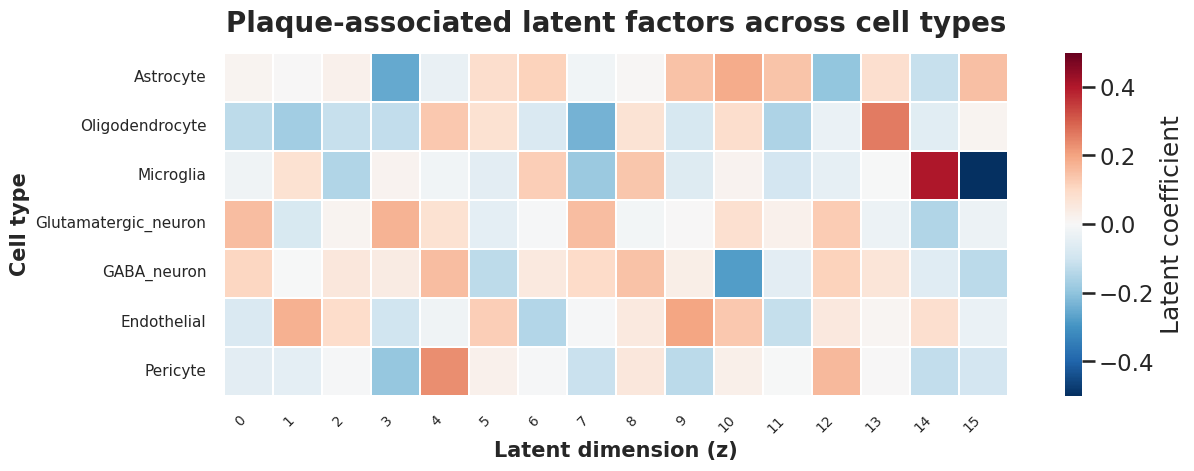

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


heatmap_data = (
    latent_results
    .pivot(
        index="celltype",
        columns="latent_dim",
        values="coefficient"
    )
)


cell_order = [
    "Astrocyte",
    "Oligodendrocyte",
    "Microglia",
    "Glutamatergic_neuron",
    "GABA_neuron",
    "Endothelial",
    "Pericyte"
]


heatmap_data = heatmap_data.loc[
    [x for x in cell_order if x in heatmap_data.index]
]


plt.figure(
    figsize=(14,5)
)


ax = sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    linecolor="white",
    square=True,
    cbar_kws={
        "label":"Latent coefficient"
    },
    vmin=-0.5,
    vmax=0.5
)


ax.set_xlabel(
    "Latent dimension (z)",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel(
    "Cell type",
    fontsize=15,
    fontweight="bold"
)


ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10
)


ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11,
)


plt.title(
    "Plaque-associated latent factors across cell types",
    fontsize=20,
    fontweight="bold",
    pad=15
)


plt.tight_layout()

plt.show()

In [164]:
import os
import numpy as np
import pandas as pd
import torch
import scanpy as sc


model_path="/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/Microglia"


checkpoint=torch.load(
    os.path.join(model_path,"vae_model.pt"),
    map_location=device
)


micro_model=VAE(
    n_gene=checkpoint["n_gene"],
    n_batch=checkpoint["n_batch"],
    latent=checkpoint["latent_dim"]
).to(device)


micro_model.load_state_dict(
    checkpoint["model_state_dict"]
)


micro_model.eval()


micro_Z=np.load(
    os.path.join(model_path,"latent.npy")
)


micro_sub=sc.read_h5ad(
    os.path.join(model_path,"subset.h5ad")
)



latent_dim=15


z_base=np.zeros(
    (1,checkpoint["latent_dim"])
)


z_low=z_base.copy()
z_high=z_base.copy()


z_low[0,latent_dim]=-3
z_high[0,latent_dim]=3



batch_id=torch.tensor(
    [0],
    dtype=torch.long
).to(device)



with torch.no_grad():

    z_low_tensor=torch.tensor(
        z_low,
        dtype=torch.float32
    ).to(device)


    z_high_tensor=torch.tensor(
        z_high,
        dtype=torch.float32
    ).to(device)


    batch_emb=micro_model.batch_emb(
        batch_id
    )


    gene_low=micro_model.decoder(
        torch.cat(
            [
                z_low_tensor,
                batch_emb
            ],
            dim=1
        )
    )


    gene_high=micro_model.decoder(
        torch.cat(
            [
                z_high_tensor,
                batch_emb
            ],
            dim=1
        )
    )



gene_diff=(
    gene_high.cpu().numpy()[0]
    -
    gene_low.cpu().numpy()[0]
)



gene_result_latent15=pd.DataFrame(
    {
        "gene":micro_sub.var_names,
        "latent15_effect":gene_diff
    }
)


gene_result_latent15["abs_effect"]=(
    gene_result_latent15["latent15_effect"]
    .abs()
)


gene_result_latent15=gene_result_latent15.sort_values(
    "latent15_effect",
    ascending=False)

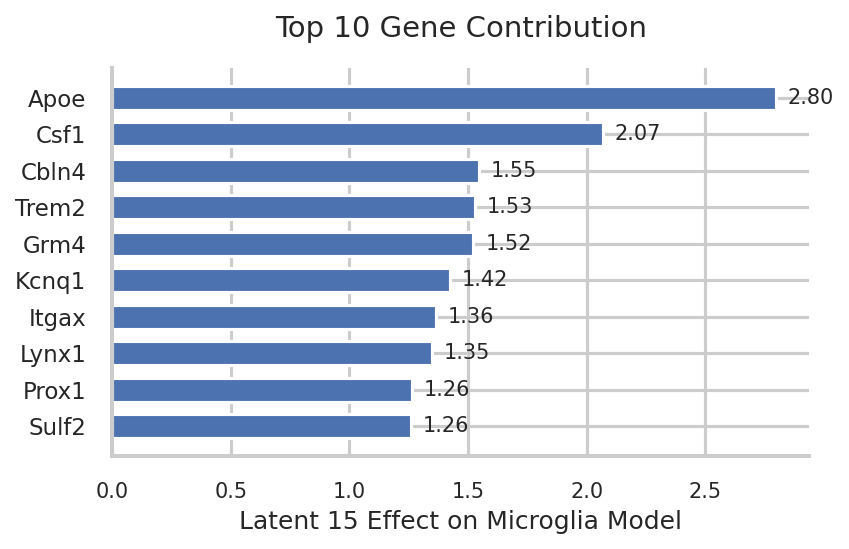

In [165]:
import matplotlib.pyplot as plt
import numpy as np


plot_df = (
    gene_result_latent15
    .sort_values(
        "latent15_effect",
        ascending=False
    )
    .head(10)
    .sort_values(
        "latent15_effect"
    )
)


plt.figure(
    figsize=(6,4),
    dpi=150
)


bars = plt.barh(
    plot_df["gene"],
    plot_df["latent15_effect"],
    height=0.65
)


plt.axvline(
    0,
    linewidth=1
)


for bar, value in zip(
    bars,
    plot_df["latent15_effect"]
):

    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )


plt.xlabel(
    "Latent 15 Effect on Microglia Model",
    fontsize=12
)

plt.ylabel(
    "",
    fontsize=12
)


plt.title(
    "Top 10 Gene Contribution",
    fontsize=14,
    pad=15
)


plt.xticks(
    fontsize=10
)

plt.yticks(
    fontsize=11
)


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


plt.tight_layout()

plt.show()

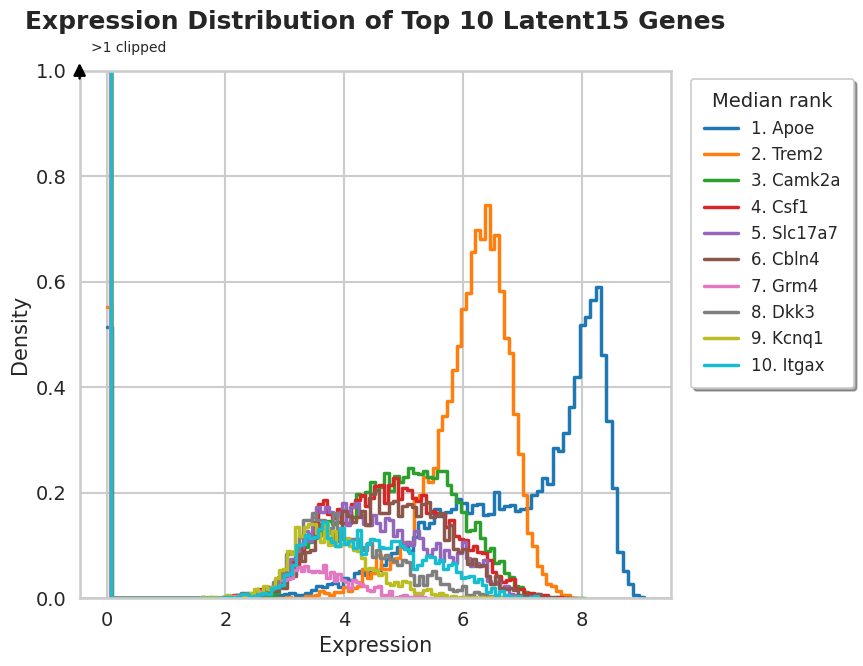

In [166]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

sns.set_theme(
    style="whitegrid",
    context="talk"
)

genes = (
    gene_result_latent15
    .sort_values("abs_effect", ascending=False)
    .head(10)["gene"]
    .tolist()
)

micro = adata[
    adata.obs["mannual_annotaion"] == "Microglia"
].copy()

X = micro.X

if sparse.issparse(X):
    X = X.toarray()

expr = pd.DataFrame(
    X,
    index=micro.obs_names,
    columns=micro.var_names
)

median_rank = (
    expr[genes]
    .median()
    .sort_values(ascending=False)
)

genes = median_rank.index.tolist()

palette = sns.color_palette("tab10", len(genes))

fig, ax = plt.subplots(figsize=(9,7))

for i, g in enumerate(genes):

    sns.histplot(
        expr[g],
        bins=100,
        stat="density",
        element="step",
        fill=False,
        linewidth=2.5,
        color=palette[i],
        label=f"{i+1}. {g}",
        ax=ax
    )

ax.set_ylim(0,1)

ax.annotate(
    "",
    xy=(0,1.02),
    xytext=(0,0.98),
    xycoords=("axes fraction","axes fraction"),
    arrowprops=dict(
        arrowstyle="-|>",
        lw=1.8,
        color="black"
    )
)

ax.text(
    0.02,
    1.035,
    ">1 clipped",
    transform=ax.transAxes,
    fontsize=10,
)

ax.set_xlabel(
    "Expression",
    fontsize=15)

ax.set_ylabel(
    "Density",
    fontsize=15)

ax.set_title(
    "Expression Distribution of Top 10 Latent15 Genes",
    fontsize=18,
    fontweight="bold",
    pad=30
)

ax.tick_params(
    axis="both",
    labelsize=14,
    width=1.5,
    length=6
)

legend = ax.legend(
    title="Median rank",
    title_fontsize=14,
    fontsize=12,
    loc="upper left",
    bbox_to_anchor=(1.02,1),
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8
)

legend.get_frame().set_linewidth(1.2)

plt.tight_layout()
plt.show()

In [31]:
################# Position compare #################

In [41]:
import scanpy as sc

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/after_bulk_ccf_annotated.h5ad")

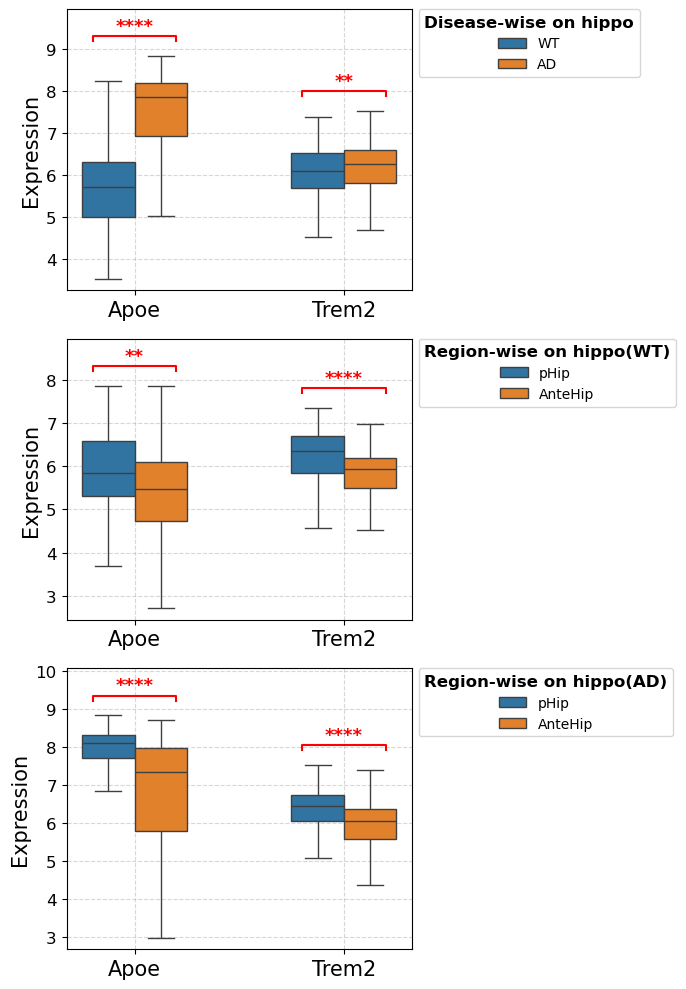

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from statannotations.Annotator import Annotator

adata = adata[adata.obs['CCF_major'] == 'Hippocampus'].copy()

genes = ["Apoe", "Trem2"]

group_width = 0.5

fig_width = 7
fig_height = 10

ylabel = "Expression"

xlabel_size = 15
ylabel_size = 15
xtick_size = 15
ytick_size = 12

star_size = 13

legend_fontsize = 10
legend_title_size = 12
legend_loc = "upper left"
legend_anchor = (1.02, 1)

micro = adata[
    adata.obs["mannual_annotaion"] == "Microglia"
].copy()

X = micro.X

if sparse.issparse(X):
    X = X.toarray()

expr = pd.DataFrame(
    X,
    index=micro.obs_names,
    columns=micro.var_names
)

plot_df = expr[genes].copy()

plot_df["genotype"] = (
    micro.obs["genotype"]
    .replace({"5xFAD": "AD"})
    .values
)

plot_df["region"] = micro.obs["region_short"].values

plot_df = plot_df.melt(
    id_vars=["genotype", "region"],
    var_name="gene",
    value_name="expression"
)

fig, axes = plt.subplots(
    3, 1, figsize=(fig_width, fig_height)
)

ax1 = axes[0]

sns.boxplot(
    data=plot_df,
    x="gene",
    y="expression",
    hue="genotype",
    hue_order=["WT", "AD"],
    width=group_width,
    showfliers=False,
    ax=ax1
)

pairs = [
    ((g, "WT"), (g, "AD"))
    for g in genes
]

annot1 = Annotator(
    ax1,
    pairs,
    data=plot_df,
    x="gene",
    y="expression",
    hue="genotype",
    order=genes,
    hue_order=["WT", "AD"]
)

annot1.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    color="red",
    verbose=0
)

annot1.apply_and_annotate()

for text in ax1.texts:
    if "*" in text.get_text():
        text.set_color("red")
        text.set_fontweight("bold")
        text.set_fontsize(star_size)

legend1 = ax1.legend(
    title="Disease-wise on hippo",
    loc=legend_loc,
    bbox_to_anchor=legend_anchor,
    borderaxespad=0,
    frameon=True,
    fontsize=legend_fontsize,
    title_fontsize=legend_title_size
)
legend1.get_title().set_fontweight("bold")

ax2 = axes[1]

plot_df_wt = plot_df[plot_df["genotype"] == "WT"].copy()

sns.boxplot(
    data=plot_df_wt,
    x="gene",
    y="expression",
    hue="region",
    hue_order=["pHip", "AnteHip"],
    width=group_width,
    showfliers=False,
    ax=ax2
)

pairs = [
    ((g, "pHip"), (g, "AnteHip"))
    for g in genes
]

annot2 = Annotator(
    ax2,
    pairs,
    data=plot_df_wt,
    x="gene",
    y="expression",
    hue="region",
    order=genes,
    hue_order=["pHip", "AnteHip"]
)

annot2.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    color="red",
    verbose=0
)

annot2.apply_and_annotate()

for text in ax2.texts:
    if "*" in text.get_text():
        text.set_color("red")
        text.set_fontweight("bold")
        text.set_fontsize(star_size)

legend2 = ax2.legend(
    title="Region-wise on hippo(WT)",
    loc=legend_loc,
    bbox_to_anchor=legend_anchor,
    borderaxespad=0,
    frameon=True,
    fontsize=legend_fontsize,
    title_fontsize=legend_title_size
)
legend2.get_title().set_fontweight("bold")

ax3 = axes[2]

plot_df_ad = plot_df[plot_df["genotype"] == "AD"].copy()

sns.boxplot(
    data=plot_df_ad,
    x="gene",
    y="expression",
    hue="region",
    hue_order=["pHip", "AnteHip"],
    width=group_width,
    showfliers=False,
    ax=ax3
)

annot3 = Annotator(
    ax3,
    pairs,
    data=plot_df_ad,
    x="gene",
    y="expression",
    hue="region",
    order=genes,
    hue_order=["pHip", "AnteHip"]
)

annot3.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    color="red",
    verbose=0
)

annot3.apply_and_annotate()

for text in ax3.texts:
    if "*" in text.get_text():
        text.set_color("red")
        text.set_fontweight("bold")
        text.set_fontsize(star_size)

legend3 = ax3.legend(
    title="Region-wise on hippo(AD)",
    loc=legend_loc,
    bbox_to_anchor=legend_anchor,
    borderaxespad=0,
    frameon=True,
    fontsize=legend_fontsize,
    title_fontsize=legend_title_size
)
legend3.get_title().set_fontweight("bold")

all_axes = [ax1, ax2, ax3]

for ax in all_axes:
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel(
        ylabel,
        fontsize=ylabel_size)
    ax.tick_params(
        axis="x",
        labelsize=xtick_size
    )
    ax.tick_params(
        axis="y",
        labelsize=ytick_size
    )
    ax.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# fGSEA (Merscope)

In [24]:
import os
import torch
import numpy as np
import scanpy as sc
import joblib


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


model_path = "/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/Microglia"


checkpoint = torch.load(
    os.path.join(model_path, "vae_model.pt"),
    map_location=device
)


model = VAE(
    n_gene=checkpoint["n_gene"],
    n_batch=checkpoint["n_batch"],
    latent=checkpoint["latent_dim"]
).to(device)


model.load_state_dict(
    checkpoint["model_state_dict"]
)


model.eval()


latent = np.load(
    os.path.join(model_path, "latent.npy")
)


adata = sc.read_h5ad(
    os.path.join(model_path, "subset.h5ad")
)


scaler = joblib.load(
    os.path.join(model_path, "scaler.pkl")
)


print(latent.shape)
print(adata.shape)

(7004, 16)
(7004, 300)


In [39]:
latent_top20_list = []

for z in microglia_latent_gene_effect["latent_dim"].unique():

    top20 = (
        microglia_latent_gene_effect[
            microglia_latent_gene_effect["latent_dim"] == z
        ]
        .sort_values(
            "effect",
            ascending=False
        )
        .head(100)
        .copy()
    )

    latent_top20_list.append(top20)


latent_top20_df = pd.concat(
    latent_top20_list,
    ignore_index=True
)


latent_top20_df

,gene,latent_dim,effect,abs_effect
0,Rorb,z0,1.270708,1.270708
1,Grm4,z0,1.173250,1.173250
2,Grm1,z0,1.027739,1.027739
3,Slc17a6,z0,0.965325,0.965325
4,Cacng5,z0,0.921638,0.921638
...,...,...,...,...
1595,Aqp4,z15,0.342676,0.342676
1596,Il1b,z15,0.339588,0.339588
1597,Hrh3,z15,0.329825,0.329825
1598,S100b,z15,0.329094,0.329094


In [40]:
file_path = "/home/Data_Drive_8TB_2/kykim/potrai/VAE_model/latent_top100_df.csv"

latent_top20_df.to_csv(file_path, index=False, encoding="utf-8-sig")

# Microglia Trem2/Apoe Neighbor Association Analysis (Merscope)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.spatial import cKDTree
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

In [2]:
ADATA_PATH = '/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/after_bulk_ccf_annotated.h5ad'
SAMPLE_COL = 'sample_id'
CELLTYPE_COL = 'mannual_annotaion'
MICROGLIA_LABEL = 'Microglia'
TARGET_GENES = ['Trem2', 'Apoe']
N_NEIGHBORS = 12
MIN_CELLS_PER_SAMPLE = 20
MIN_VARIANCE = 1e-6

print('adata path:', ADATA_PATH)
print('sample column:', SAMPLE_COL)
print('cell type column:', CELLTYPE_COL)
print('target genes:', TARGET_GENES)
print('neighbors per cell:', N_NEIGHBORS)

adata path: /home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/after_bulk_ccf_annotated.h5ad
sample column: sample_id
cell type column: mannual_annotaion
target genes: ['Trem2', 'Apoe']
neighbors per cell: 12


In [3]:
adata = ad.read_h5ad(ADATA_PATH)
print(adata)

required = [SAMPLE_COL, CELLTYPE_COL, 'center_x', 'center_y']
missing = [c for c in required if c not in adata.obs.columns]
if missing:
    raise KeyError(f'Missing required obs columns: {missing}')

for g in TARGET_GENES:
    if g not in adata.var_names:
        raise KeyError(f'Missing target gene in var_names: {g}')

print('samples:', adata.obs[SAMPLE_COL].astype(str).nunique())
print('cell types:', adata.obs[CELLTYPE_COL].astype(str).nunique())
print('microglia cells:', int(adata.obs[CELLTYPE_COL].astype(str).str.contains(MICROGLIA_LABEL, case=False, regex=False).sum()))
print('obsm keys:', list(adata.obsm.keys()))
print('top cell types:')
display(adata.obs[CELLTYPE_COL].astype(str).value_counts().head(15).to_frame('n_cells'))

AnnData object with n_obs × n_vars = 136456 × 300
    obs: 'fov', 'center_x', 'center_y', 'x_min', 'x_max', 'y_min', 'y_max', 'volume', 'sample_id', 'genotype', 'strain', 'sex', 'age', 'region_location', 'region_short', 'trem2_mutation', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_300_genes', '_scvi_batch', '_scvi_labels', 'batch', 'dataset', 'class_pred', 'class_score', 'subclass_pred', 'subclass_score', 'supertype_pred', 'supertype_score', 'cluster_pred', 'cluster_score', 'final_label_transfer', 'leiden_res_0.50', 'leiden_res_0.75', 'leiden_res_1.00', 'leiden_res_1.25', 'leiden_res_0.10', 'leiden_res_0.25', 'Mannual_annotaion', 'mannual_annotaion', 'x_mosaic_px', 'y_mosaic_px', 'x_ccf_vox', 'y_ccf_vox', 'z_ccf_vox', 'ccf_reg_mode', 'cc

,n_cells
mannual_annotaion,
Glutamatergic_neuron,34891
Oligodendrocyte,31874
GABA_neuron,22163
Astrocyte,20314
Endothelial,10167
Microglia,9591
Pericyte,7109
Catecholaminergic_neuron,347


In [4]:
def to_dense(x):
    if sp.issparse(x):
        return x.toarray()
    return np.asarray(x)

def get_spatial_coords(adata_obj):
    if 'spatial' in adata_obj.obsm:
        return np.asarray(adata_obj.obsm['spatial'])
    return adata_obj.obs[['center_x', 'center_y']].to_numpy(dtype=float)

def is_microglia_series(series):
    return series.astype(str).str.contains(MICROGLIA_LABEL, case=False, regex=False)

coords = get_spatial_coords(adata)
print('spatial coords shape:', coords.shape)

obs = adata.obs[[SAMPLE_COL, CELLTYPE_COL, 'center_x', 'center_y']].copy()
obs['cell_id'] = adata.obs_names.astype(str).values
obs['is_microglia'] = is_microglia_series(obs[CELLTYPE_COL])

gene_expr = to_dense(adata[:, TARGET_GENES].X)
if gene_expr.ndim == 1:
    gene_expr = gene_expr.reshape(-1, 1)

obs['log1p_Trem2'] = np.log1p(gene_expr[:, TARGET_GENES.index('Trem2')])
obs['log1p_Apoe'] = np.log1p(gene_expr[:, TARGET_GENES.index('Apoe')])

spatial coords shape: (136456, 2)


In [5]:
microglia_rows = []
partner_types_global = sorted([t for t in obs[CELLTYPE_COL].astype(str).unique().tolist() if t.lower() != MICROGLIA_LABEL.lower()])

for sid, idx_labels in obs.groupby(SAMPLE_COL).groups.items():
    idx = obs.index.get_indexer(idx_labels)
    sub_obs = obs.iloc[idx].copy()
    sub_coords = coords[idx]
    sub_types = sub_obs[CELLTYPE_COL].astype(str).to_numpy()
    sub_expr = gene_expr[idx, :]

    tree = cKDTree(sub_coords)
    _, nn = tree.query(sub_coords, k=min(N_NEIGHBORS + 1, len(sub_coords)))
    if nn.ndim == 1:
        nn = nn[:, None]

    neighbor_idx = nn[:, 1:]
    micro_idx = np.where(sub_obs[CELLTYPE_COL].astype(str).str.contains(MICROGLIA_LABEL, case=False, regex=False).values)[0]
    if len(micro_idx) == 0:
        continue

    for i in micro_idx:
        nbr = neighbor_idx[i]
        nbr_types = pd.Series(sub_types[nbr]).value_counts()
        row = {
            'sample_id': str(sid),
            'cell_id': sub_obs.iloc[i]['cell_id'],
            'cell_type': sub_obs.iloc[i][CELLTYPE_COL],
            'n_neighbors': int(len(nbr)),
            'microglia_neighbor_fraction': float((sub_types[nbr] == MICROGLIA_LABEL).mean()),
            'log1p_Trem2': float(np.log1p(sub_expr[i, TARGET_GENES.index('Trem2')])),
            'log1p_Apoe': float(np.log1p(sub_expr[i, TARGET_GENES.index('Apoe')]))
        }
        for partner in partner_types_global:
            row[f'frac__{partner}'] = float(nbr_types.get(partner, 0) / len(nbr))
            row[f'count__{partner}'] = int(nbr_types.get(partner, 0))
        microglia_rows.append(row)

micro_df = pd.DataFrame(microglia_rows)
if micro_df.empty:
    raise RuntimeError('No microglia rows were created. Check spatial coordinates and labels.')

print('microglia rows:', len(micro_df))
print('samples in micro_df:', micro_df['sample_id'].nunique())
display(micro_df.head())

microglia rows: 9591
samples in micro_df: 4


,sample_id,cell_id,cell_type,n_neighbors,microglia_neighbor_fraction,log1p_Trem2,log1p_Apoe,frac__Astrocyte,count__Astrocyte,frac__Catecholaminergic_neuron,count__Catecholaminergic_neuron,frac__Endothelial,count__Endothelial,frac__GABA_neuron,count__GABA_neuron,frac__Glutamatergic_neuron,count__Glutamatergic_neuron,frac__Oligodendrocyte,count__Oligodendrocyte,frac__Pericyte,count__Pericyte
0,5xFAD1,5xFAD1_cell_in_reg_0_10_Z_0_fov_1928_1624804,Microglia,12,0.083333,2.064846,2.208248,0.166667,2,0.0,0,0.083333,1,0.000000,0,0.500000,6,0.166667,2,0.000000,0
1,5xFAD1,5xFAD1_cell_in_reg_0_21_Z_0_fov_1928_3151025,Microglia,12,0.083333,2.058793,2.157194,0.083333,1,0.0,0,0.166667,2,0.083333,1,0.333333,4,0.250000,3,0.000000,0
2,5xFAD1,5xFAD1_cell_in_reg_0_44_Z_0_fov_1928_3494498,Microglia,12,0.000000,2.068228,2.180942,0.000000,0,0.0,0,0.083333,1,0.166667,2,0.666667,8,0.083333,1,0.000000,0
3,5xFAD1,5xFAD1_cell_in_reg_0_53_Z_0_fov_1928_4531570,Microglia,12,0.000000,1.996459,2.061118,0.166667,2,0.0,0,0.083333,1,0.250000,3,0.250000,3,0.166667,2,0.083333,1
4,5xFAD1,5xFAD1_cell_in_reg_0_84_Z_0_fov_1928_8149195,Microglia,12,0.083333,2.077770,0.000000,0.083333,1,0.0,0,0.000000,0,0.000000,0,0.500000,6,0.333333,4,0.000000,0


In [6]:
micro_df['z_Trem2'] = micro_df.groupby('sample_id')['log1p_Trem2'].transform(lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0.0)
micro_df['z_Apoe'] = micro_df.groupby('sample_id')['log1p_Apoe'].transform(lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0.0)

partner_cols = [c for c in micro_df.columns if c.startswith('frac__')]
gene_map = {'Trem2': 'z_Trem2', 'Apoe': 'z_Apoe'}
results = []

for gene_name, response_col in gene_map.items():
    for partner_col in partner_cols:
        tmp = micro_df[[response_col, partner_col, 'n_neighbors', 'sample_id']].dropna().copy()
        if len(tmp) < MIN_CELLS_PER_SAMPLE * micro_df['sample_id'].nunique():
            continue
        if tmp[partner_col].nunique() < 2 or tmp[response_col].var(ddof=0) < MIN_VARIANCE:
            continue

        formula = f'{response_col} ~ {partner_col} + n_neighbors + C(sample_id)'
        fit = ols(formula, data=tmp).fit(cov_type='HC3')
        beta = float(fit.params.get(partner_col, np.nan))
        pval = float(fit.pvalues.get(partner_col, np.nan))

        per_sample_signs = []
        for sid, sub in tmp.groupby('sample_id'):
            if sub[partner_col].nunique() < 2 or sub[response_col].nunique() < 2:
                continue
            corr = sub[[response_col, partner_col]].corr(method='spearman').iloc[0, 1]
            if pd.notna(corr):
                per_sample_signs.append(np.sign(corr))

        signed_consistency = np.nan
        if per_sample_signs:
            signed_consistency = float(abs(np.sum(per_sample_signs)) / len(per_sample_signs))

        results.append({
            'gene': gene_name,
            'partner_type': partner_col.replace('frac__', ''),
            'beta': beta,
            'pvalue': pval,
            'n_cells': int(len(tmp)),
            'n_samples': int(tmp['sample_id'].nunique()),
            'signed_consistency': signed_consistency
        })

res = pd.DataFrame(results)
if res.empty:
    raise RuntimeError('No regression results were generated. Try lowering MIN_CELLS_PER_SAMPLE.')

res['fdr_bh'] = np.nan
for gene_name in gene_map:
    mask = res['gene'].eq(gene_name)
    pvals = res.loc[mask, 'pvalue'].to_numpy()
    if len(pvals) > 0:
        _, qvals, _, _ = multipletests(pvals, method='fdr_bh')
        res.loc[mask, 'fdr_bh'] = qvals

res = res.sort_values(['gene', 'fdr_bh', 'pvalue', 'beta'], ascending=[True, True, True, False])
display(res.head(30))

,gene,partner_type,beta,pvalue,n_cells,n_samples,signed_consistency,fdr_bh
11,Apoe,Glutamatergic_neuron,-0.726592,6.806012e-54,9591,4,1.000000,4.764208e-53
12,Apoe,Oligodendrocyte,0.622268,3.359626e-37,9591,4,1.000000,1.175869e-36
10,Apoe,GABA_neuron,0.148377,2.384734e-02,9591,4,0.000000,5.564379e-02
7,Apoe,Astrocyte,0.088288,2.203279e-01,9591,4,0.000000,3.855738e-01
9,Apoe,Endothelial,-0.136008,2.936575e-01,9591,4,0.500000,4.111205e-01
13,Apoe,Pericyte,0.084024,6.137084e-01,9591,4,1.000000,7.159931e-01
8,Apoe,Catecholaminergic_neuron,-0.283246,7.474185e-01,9591,4,0.333333,7.474185e-01
5,Trem2,Oligodendrocyte,0.194955,1.484245e-04,9591,4,1.000000,1.038971e-03
6,Trem2,Pericyte,-0.551023,3.251930e-03,9591,4,0.500000,1.138176e-02
4,Trem2,Glutamatergic_neuron,-0.115852,4.949596e-03,9591,4,0.500000,1.154906e-02


Top positive associations


,gene,partner_type,beta,pvalue,n_cells,n_samples,signed_consistency,fdr_bh
12,Apoe,Oligodendrocyte,0.622268,3.359626e-37,9591,4,1.000000,1.175869e-36
10,Apoe,GABA_neuron,0.148377,2.384734e-02,9591,4,0.000000,5.564379e-02
7,Apoe,Astrocyte,0.088288,2.203279e-01,9591,4,0.000000,3.855738e-01
13,Apoe,Pericyte,0.084024,6.137084e-01,9591,4,1.000000,7.159931e-01
5,Trem2,Oligodendrocyte,0.194955,1.484245e-04,9591,4,1.000000,1.038971e-03
3,Trem2,GABA_neuron,0.127187,3.787155e-02,9591,4,0.500000,6.627520e-02
1,Trem2,Catecholaminergic_neuron,0.322323,2.395896e-01,9591,4,0.333333,2.795212e-01
2,Trem2,Endothelial,0.101803,4.199259e-01,9591,4,1.000000,4.199259e-01


Top negative associations


,gene,partner_type,beta,pvalue,n_cells,n_samples,signed_consistency,fdr_bh
11,Apoe,Glutamatergic_neuron,-0.726592,6.806012e-54,9591,4,1.000000,4.764208e-53
9,Apoe,Endothelial,-0.136008,2.936575e-01,9591,4,0.500000,4.111205e-01
8,Apoe,Catecholaminergic_neuron,-0.283246,7.474185e-01,9591,4,0.333333,7.474185e-01
6,Trem2,Pericyte,-0.551023,3.251930e-03,9591,4,0.500000,1.138176e-02
4,Trem2,Glutamatergic_neuron,-0.115852,4.949596e-03,9591,4,0.500000,1.154906e-02
0,Trem2,Astrocyte,-0.119075,1.177979e-01,9591,4,0.000000,1.649171e-01


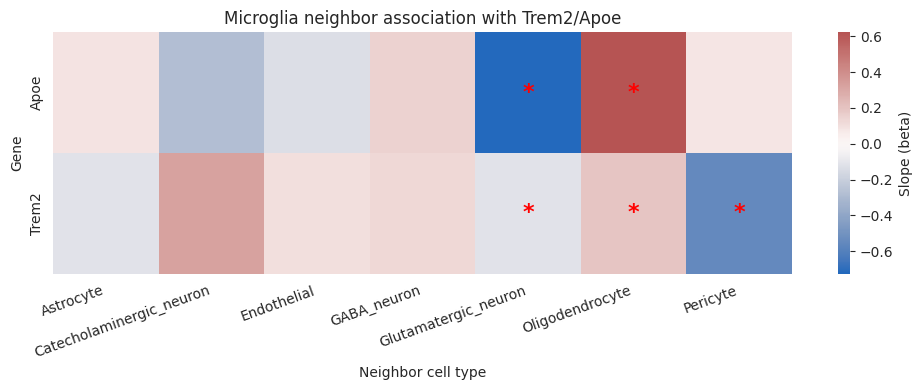

In [24]:
positive = res.query("beta > 0").sort_values(
    ["gene", "fdr_bh", "beta"], ascending=[True, True, False]
)
negative = res.query("beta < 0").sort_values(
    ["gene", "fdr_bh", "beta"], ascending=[True, True, True]
)

print("Top positive associations")
display(positive.groupby("gene").head(10))

print("Top negative associations")
display(negative.groupby("gene").head(10))

heat = res.pivot(index="gene", columns="partner_type", values="beta").fillna(0)

p_col = "fdr_bh" if "fdr_bh" in res.columns else "p_val"
heat_p = res.pivot(index="gene", columns="partner_type", values=p_col).fillna(1)
annot_matrix = np.where(heat_p < 0.05, "*", "")

plt.figure(figsize=(max(10, 0.3 * heat.shape[1]), 4))

ax = sns.heatmap(
    heat,
    cmap="vlag",
    center=0,
    annot=annot_matrix,
    fmt="",
    annot_kws={"size": 16, "color": "red", "weight": "bold", "va": "center"},
    cbar_kws={"label": "Slope (beta)"},
)

plt.xticks(rotation=20, ha="right")
plt.title("Microglia neighbor association with Trem2/Apoe")
plt.xlabel("Neighbor cell type")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

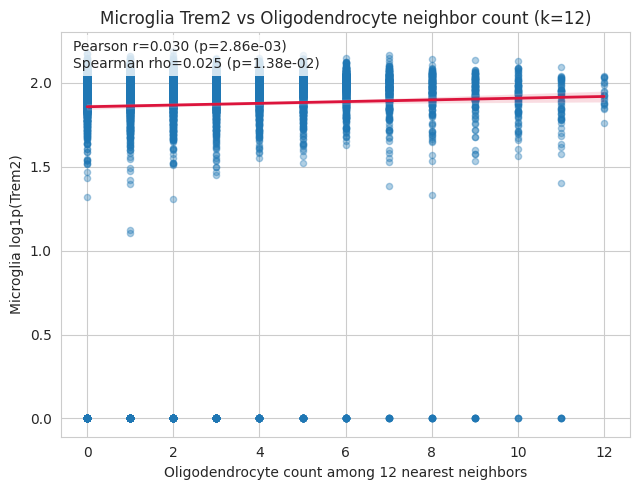

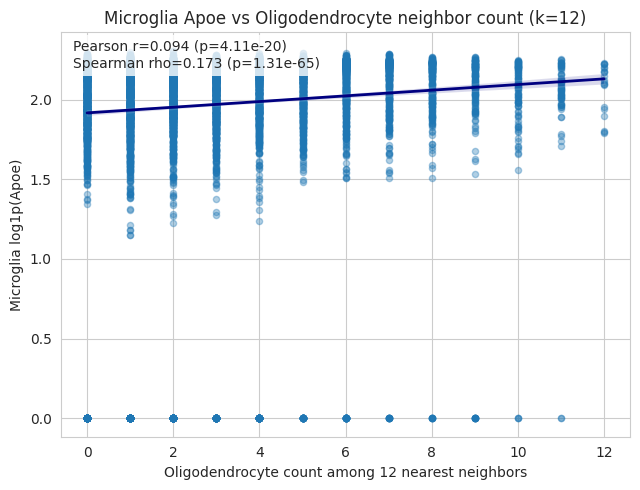

In [8]:
from scipy.stats import pearsonr, spearmanr

oligo_col = 'count__Oligodendrocyte'
if oligo_col not in micro_df.columns:
    raise KeyError(f'{oligo_col} not found in micro_df. Available count columns: {[c for c in micro_df.columns if c.startswith("count__")]}')

plot_df = micro_df[[oligo_col, 'log1p_Trem2', 'log1p_Apoe']].dropna().copy()

x = plot_df[oligo_col].to_numpy()

# Figure 1: Oligodendrocyte neighbor count vs Trem2
y_trem2 = plot_df['log1p_Trem2'].to_numpy()
rp_t, pp_t = pearsonr(x, y_trem2)
rs_t, ps_t = spearmanr(x, y_trem2)

plt.figure(figsize=(6.5, 5))
sns.regplot(
    data=plot_df,
    x=oligo_col,
    y='log1p_Trem2',
    scatter_kws={'s': 20, 'alpha': 0.35},
    line_kws={'color': 'crimson', 'lw': 2}
)
plt.title('Microglia Trem2 vs Oligodendrocyte neighbor count (k=12)')
plt.xlabel('Oligodendrocyte count among 12 nearest neighbors')
plt.ylabel('Microglia log1p(Trem2)')
plt.text(
    0.02,
    0.98,
    f'Pearson r={rp_t:.3f} (p={pp_t:.2e})\nSpearman rho={rs_t:.3f} (p={ps_t:.2e})',
    transform=plt.gca().transAxes,
    va='top',
    ha='left',
    bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'}
)
plt.tight_layout()
plt.show()

# Figure 2: Oligodendrocyte neighbor count vs Apoe
y_apoe = plot_df['log1p_Apoe'].to_numpy()
rp_a, pp_a = pearsonr(x, y_apoe)
rs_a, ps_a = spearmanr(x, y_apoe)

plt.figure(figsize=(6.5, 5))
sns.regplot(
    data=plot_df,
    x=oligo_col,
    y='log1p_Apoe',
    scatter_kws={'s': 20, 'alpha': 0.35},
    line_kws={'color': 'navy', 'lw': 2}
)
plt.title('Microglia Apoe vs Oligodendrocyte neighbor count (k=12)')
plt.xlabel('Oligodendrocyte count among 12 nearest neighbors')
plt.ylabel('Microglia log1p(Apoe)')
plt.text(
    0.02,
    0.98,
    f'Pearson r={rp_a:.3f} (p={pp_a:.2e})\nSpearman rho={rs_a:.3f} (p={ps_a:.2e})',
    transform=plt.gca().transAxes,
    va='top',
    ha='left',
    bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'}
)
plt.tight_layout()
plt.show()

In [9]:
OUT_CSV = 'microglia_neighbor_association_trem2_apoe.csv'
res.to_csv(OUT_CSV, index=False)
print('saved:', OUT_CSV)

saved: microglia_neighbor_association_trem2_apoe.csv


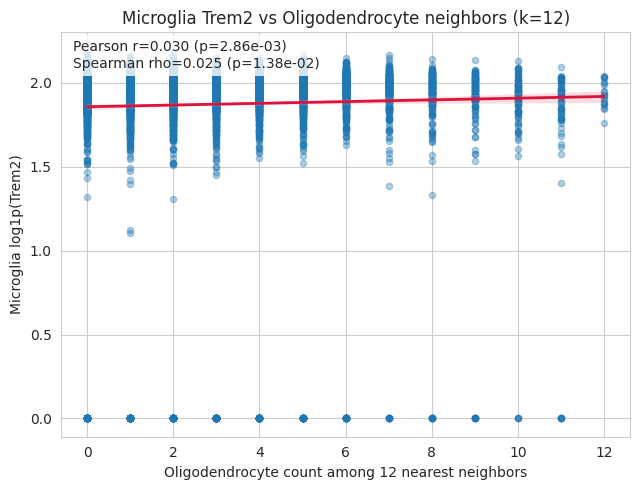

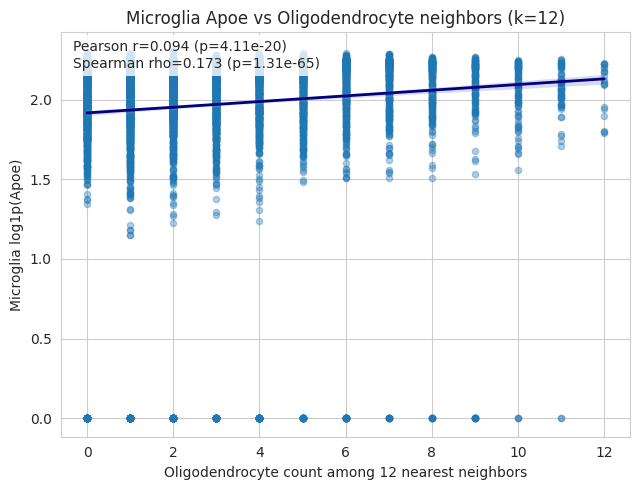

In [10]:
from scipy.stats import pearsonr, spearmanr

oligo_col = 'count__Oligodendrocyte'
if oligo_col not in micro_df.columns:
    raise KeyError(f'{oligo_col} not found. Available: {[c for c in micro_df.columns if c.startswith("count__")]}')

plot_df = micro_df[[oligo_col, 'log1p_Trem2', 'log1p_Apoe']].dropna().copy()

# Plot 1: Trem2
rp_t, pp_t = pearsonr(plot_df[oligo_col], plot_df['log1p_Trem2'])
rs_t, ps_t = spearmanr(plot_df[oligo_col], plot_df['log1p_Trem2'])

plt.figure(figsize=(6.5, 5))
sns.regplot(
    data=plot_df,
    x=oligo_col,
    y='log1p_Trem2',
    scatter_kws={'s': 20, 'alpha': 0.35},
    line_kws={'color': 'crimson', 'lw': 2}
)
plt.title('Microglia Trem2 vs Oligodendrocyte neighbors (k=12)')
plt.xlabel('Oligodendrocyte count among 12 nearest neighbors')
plt.ylabel('Microglia log1p(Trem2)')
plt.text(
    0.02,
    0.98,
    f'Pearson r={rp_t:.3f} (p={pp_t:.2e})\nSpearman rho={rs_t:.3f} (p={ps_t:.2e})',
    transform=plt.gca().transAxes,
    va='top',
    ha='left',
    bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'}
)
plt.tight_layout()
plt.show()

# Plot 2: Apoe
rp_a, pp_a = pearsonr(plot_df[oligo_col], plot_df['log1p_Apoe'])
rs_a, ps_a = spearmanr(plot_df[oligo_col], plot_df['log1p_Apoe'])

plt.figure(figsize=(6.5, 5))
sns.regplot(
    data=plot_df,
    x=oligo_col,
    y='log1p_Apoe',
    scatter_kws={'s': 20, 'alpha': 0.35},
    line_kws={'color': 'navy', 'lw': 2}
)
plt.title('Microglia Apoe vs Oligodendrocyte neighbors (k=12)')
plt.xlabel('Oligodendrocyte count among 12 nearest neighbors')
plt.ylabel('Microglia log1p(Apoe)')
plt.text(
    0.02,
    0.98,
    f'Pearson r={rp_a:.3f} (p={pp_a:.2e})\nSpearman rho={rs_a:.3f} (p={ps_a:.2e})',
    transform=plt.gca().transAxes,
    va='top',
    ha='left',
    bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'}
)
plt.tight_layout()
plt.show()

In [151]:
import scanpy as sc

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/after_bulk_ccf_annotated.h5ad")

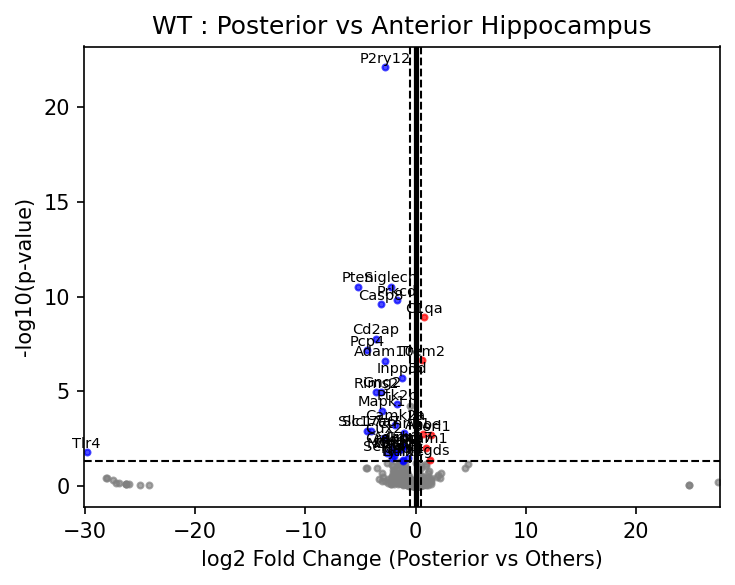

In [216]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

adata_sub = adata[
    (adata.obs["genotype"] == "WT") &
    (adata.obs["CCF_major"] == "Hippocampus") &
    (adata.obs["mannual_annotaion"] == "Microglia")
].copy()

sc.tl.rank_genes_groups(
    adata_sub,
    groupby="region_location",
    groups=["Posterior Hippocampus"],
    reference="rest",
    method="wilcoxon"
)

deg = sc.get.rank_genes_groups_df(
    adata_sub,
    group="Posterior Hippocampus"
)

deg["-log10_pvalue"] = -np.log10(deg["pvals"])

deg["significance"] = "NS"

deg.loc[
    (deg["pvals"] < 0.05) &
    (deg["logfoldchanges"] > 0.5),
    "significance"
] = "Up"

deg.loc[
    (deg["pvals"] < 0.05) &
    (deg["logfoldchanges"] < -0.5),
    "significance"
] = "Down"

plt.figure(
    figsize=(5,4),
    dpi=150
)

colors = {
    "Up": "red",
    "Down": "blue",
    "NS": "gray"
}

for label in ["NS", "Down", "Up"]:
    df = deg[deg["significance"] == label]

    plt.scatter(
        df["logfoldchanges"],
        df["-log10_pvalue"],
        s=8,
        c=colors[label],
        alpha=0.7
    )

plt.axvline(
    0,
    color="black",
    linewidth=2.5
)

plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    color="black",
    linewidth=1
)

plt.axvline(
    0.5,
    linestyle="--",
    color="black",
    linewidth=1
)

plt.axvline(
    -0.5,
    linestyle="--",
    color="black",
    linewidth=1
)

label_df = deg[
    (deg["pvals"] < 0.05) &
    (deg["logfoldchanges"].abs() >= 0.5)
]

for _, row in label_df.iterrows():
    plt.text(
        row["logfoldchanges"],
        row["-log10_pvalue"] + 0.08,
        row["names"],
        fontsize=7,
        ha="center",
        va="bottom"
    )

plt.xlabel("log2 Fold Change (Posterior vs Others)")
plt.ylabel("-log10(p-value)")
plt.title("WT : Posterior vs Anterior Hippocampus")

plt.xlim(
    deg["logfoldchanges"].min() - 0.2,
    deg["logfoldchanges"].max() + 0.2
)

plt.tight_layout()
plt.show()

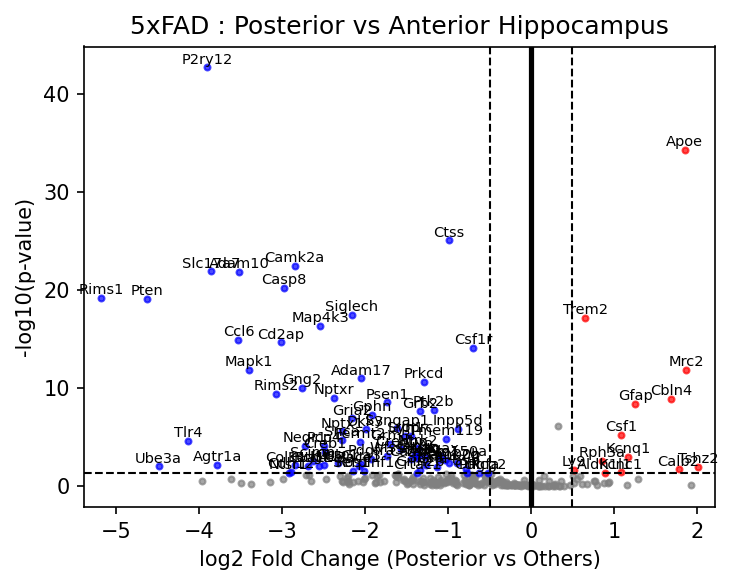

In [217]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

adata_sub = adata[
    (adata.obs["genotype"] == "5xFAD") &
    (adata.obs["CCF_major"] == "Hippocampus") &
    (adata.obs["mannual_annotaion"] == "Microglia")
].copy()

sc.tl.rank_genes_groups(
    adata_sub,
    groupby="region_location",
    groups=["Posterior Hippocampus"],
    reference="rest",
    method="wilcoxon"
)

deg = sc.get.rank_genes_groups_df(
    adata_sub,
    group="Posterior Hippocampus"
)

deg["-log10_pvalue"] = -np.log10(deg["pvals"])

deg["significance"] = "NS"

deg.loc[
    (deg["pvals"] < 0.05) &
    (deg["logfoldchanges"] > 0.5),
    "significance"
] = "Up"

deg.loc[
    (deg["pvals"] < 0.05) &
    (deg["logfoldchanges"] < -0.5),
    "significance"
] = "Down"

plt.figure(
    figsize=(5,4),
    dpi=150
)

colors = {
    "Up": "red",
    "Down": "blue",
    "NS": "gray"
}

for label in ["NS", "Down", "Up"]:
    df = deg[deg["significance"] == label]

    plt.scatter(
        df["logfoldchanges"],
        df["-log10_pvalue"],
        s=8,
        c=colors[label],
        alpha=0.7
    )

plt.axvline(
    0,
    color="black",
    linewidth=2.5
)

plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    color="black",
    linewidth=1
)

plt.axvline(
    0.5,
    linestyle="--",
    color="black",
    linewidth=1
)

plt.axvline(
    -0.5,
    linestyle="--",
    color="black",
    linewidth=1
)

label_df = deg[
    (deg["pvals"] < 0.05) &
    (deg["logfoldchanges"].abs() >= 0.5)
]

for _, row in label_df.iterrows():
    plt.text(
        row["logfoldchanges"],
        row["-log10_pvalue"] + 0.08,
        row["names"],
        fontsize=7,
        ha="center",
        va="bottom"
    )

plt.xlabel("log2 Fold Change (Posterior vs Others)")
plt.ylabel("-log10(p-value)")
plt.title("5xFAD : Posterior vs Anterior Hippocampus")

plt.xlim(
    deg["logfoldchanges"].min() - 0.2,
    deg["logfoldchanges"].max() + 0.2
)

plt.tight_layout()
plt.show()

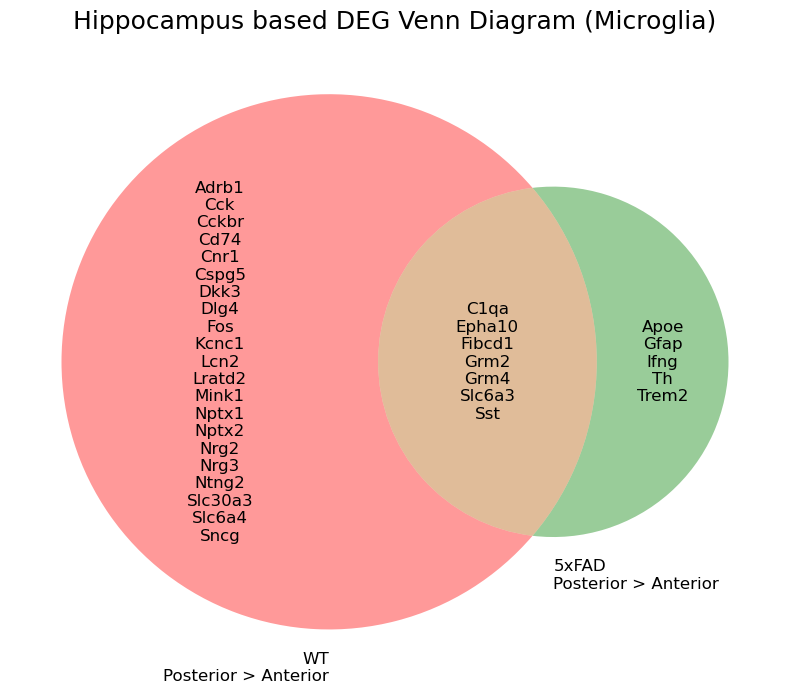

In [220]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

deg_wt_up = set(
    deg_wt.loc[
        (deg_wt["pvals"] < 0.05) &
        (deg_wt["logfoldchanges"] > 0.5),
        "names"
    ]
)

deg_fad_up = set(
    deg_fad.loc[
        (deg_fad["pvals"] < 0.05) &
        (deg_fad["logfoldchanges"] > 0.5),
        "names"
    ]
)

plt.figure(figsize=(8, 8))

v = venn2(
    [deg_wt_up, deg_fad_up],
    set_labels=(
        "WT\nPosterior > Anterior",
        "5xFAD\nPosterior > Anterior"
    )
)

wt_only = sorted(deg_wt_up - deg_fad_up)
fad_only = sorted(deg_fad_up - deg_wt_up)
shared = sorted(deg_wt_up & deg_fad_up)

v.get_label_by_id("10").set_text("\n".join(wt_only))
v.get_label_by_id("01").set_text("\n".join(fad_only))
v.get_label_by_id("11").set_text("\n".join(shared))

for sid in ["10", "01", "11"]:
    label = v.get_label_by_id(sid)
    if label is not None:
        label.set_fontsize(12)

plt.title(
    "Hippocampus based DEG Venn Diagram (Microglia)",
    fontsize=18,
    pad=10
)

plt.tight_layout()
plt.show()

In [219]:
print("WT Posterior > Anterior only")
print(wt_only)

print("\n5xFAD Posterior > Anterior only")
print(fad_only)

print("\nShared genes")
print(shared)

WT Posterior > Anterior only
['Adrb1', 'Cck', 'Cckbr', 'Cd74', 'Cnr1', 'Cspg5', 'Dkk3', 'Dlg4', 'Fos', 'Kcnc1', 'Lcn2', 'Lratd2', 'Mink1', 'Nptx1', 'Nptx2', 'Nrg2', 'Nrg3', 'Ntng2', 'Slc30a3', 'Slc6a4', 'Sncg']

5xFAD Posterior > Anterior only
['Apoe', 'Gfap', 'Ifng', 'Th', 'Trem2']

Shared genes
['C1qa', 'Epha10', 'Fibcd1', 'Grm2', 'Grm4', 'Slc6a3', 'Sst']


/tmp/ipykernel_288124/3673180081.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0,0.95])
/tmp/ipykernel_288124/3673180081.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0,0,0,0.95])


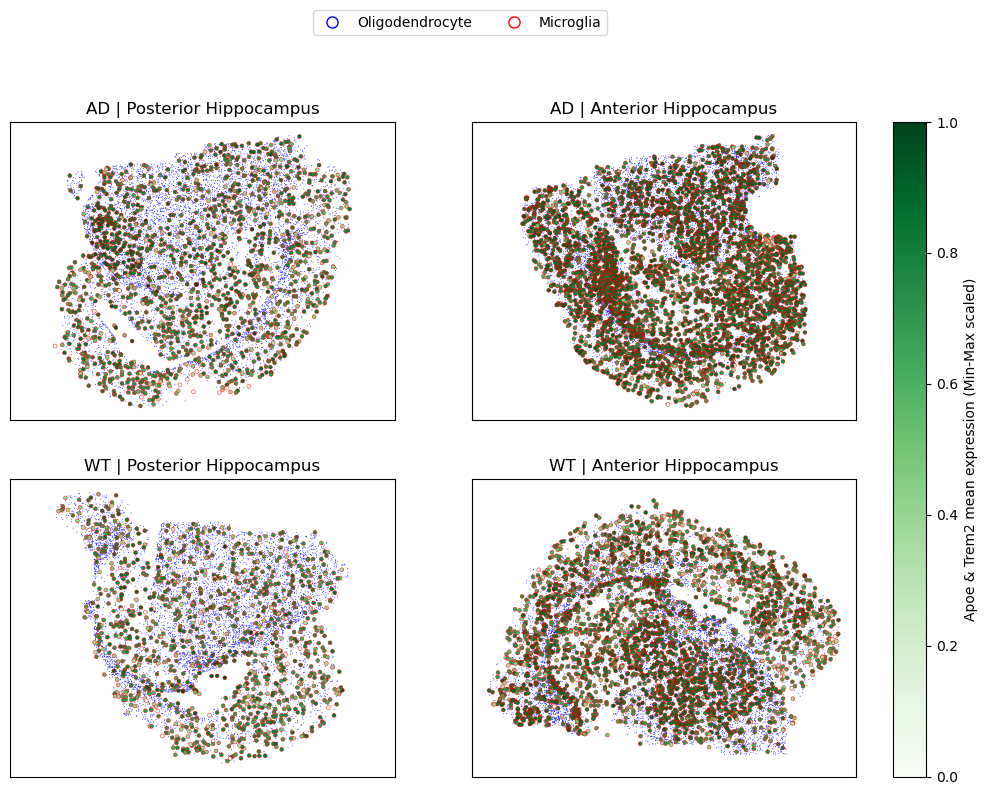

In [125]:
import matplotlib.pyplot as plt
import numpy as np

adata_sub = adata[adata.obs["mannual_annotaion"].isin(["Microglia","Oligodendrocyte"])].copy()

samples = adata_sub.obs["sample_id"].unique()

sample_title = {
    samples[0]: "AD | Posterior Hippocampus",
    samples[1]: "AD | Anterior Hippocampus",
    samples[2]: "WT | Posterior Hippocampus",
    samples[3]: "WT | Anterior Hippocampus"
}

apoe_idx = adata_sub.var_names.get_loc("Apoe")
trem2_idx = adata_sub.var_names.get_loc("Trem2")

fig, axes = plt.subplots(2, 2, figsize=(12,8.5))
axes = axes.flatten()

for ax, s in zip(axes, samples):
    tmp = adata_sub[adata_sub.obs["sample_id"] == s]
    
    xy = tmp.obsm["spatial"]
    
    micro = tmp.obs["mannual_annotaion"] == "Microglia"
    oligo = tmp.obs["mannual_annotaion"] == "Oligodendrocyte"
    
    ax.scatter(
        xy[oligo,0],
        xy[oligo,1],
        s=0.1,
        facecolors="none",
        edgecolors="blue",
        linewidths=0.3
    )
    
    apoe = tmp[micro].X[:, apoe_idx]
    trem2 = tmp[micro].X[:, trem2_idx]
    
    if hasattr(apoe, "toarray"):
        apoe = apoe.toarray().flatten()
        trem2 = trem2.toarray().flatten()
    else:
        apoe = np.array(apoe).flatten()
        trem2 = np.array(trem2).flatten()
    
    expr = (apoe + trem2) / 2
    expr = (expr - expr.min()) / (expr.max() - expr.min())
    
    sc = ax.scatter(
        xy[micro,0],
        xy[micro,1],
        s=8,
        c=expr,
        cmap="Greens",
        edgecolors="red",
        linewidths=0.3
    )
    
    ax.set_title(sample_title[s], fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("equal")
    ax.invert_yaxis()

fig.colorbar(
    sc,
    ax=axes,
    fraction=0.05,
    pad=0.04,
    label="Apoe & Trem2 mean expression (Min-Max scaled)"
)

handles = [
    plt.Line2D(
        [],
        [],
        marker='o',
        linestyle='none',
        markerfacecolor='none',
        markeredgecolor='blue',
        markersize=8,
        label='Oligodendrocyte'
    ),
    plt.Line2D(
        [],
        [],
        marker='o',
        linestyle='none',
        markerfacecolor='none',
        markeredgecolor='red',
        markersize=8,
        label='Microglia'
    )
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout(rect=[0,0,0,0.95])
plt.show()

/tmp/ipykernel_288124/3036647528.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0,0.95])
/tmp/ipykernel_288124/3036647528.py:121: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0,0,0,0.95])


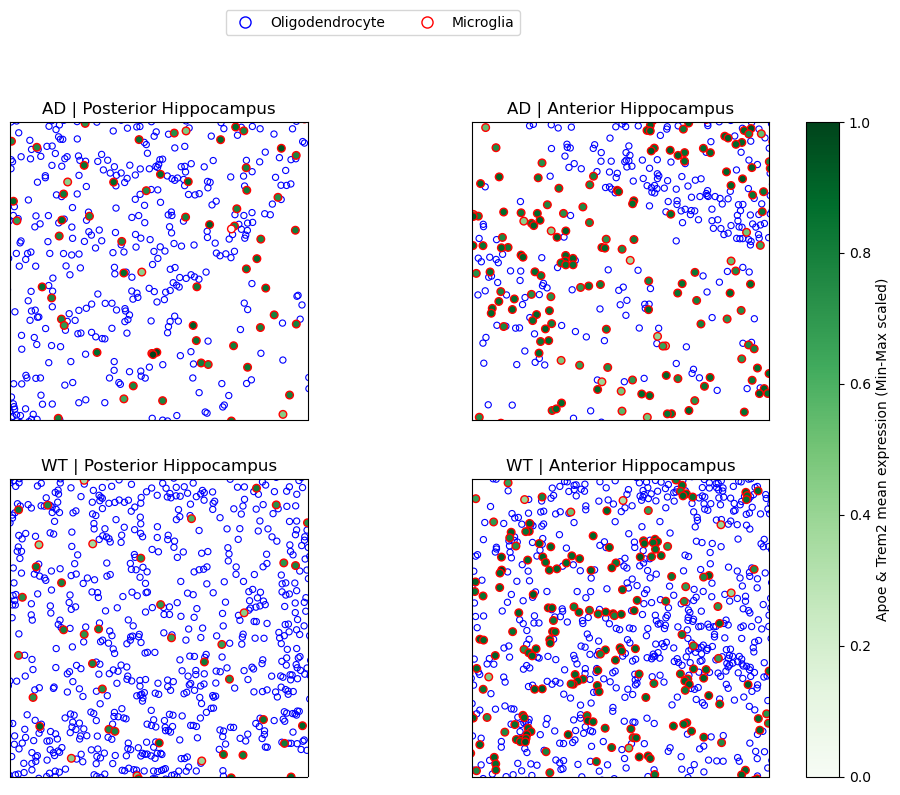

In [136]:
import matplotlib.pyplot as plt
import numpy as np

adata_sub = adata[adata.obs["mannual_annotaion"].isin(["Microglia","Oligodendrocyte"])].copy()

samples = adata_sub.obs["sample_id"].unique()

sample_title = {
    samples[0]: "AD | Posterior Hippocampus",
    samples[1]: "AD | Anterior Hippocampus",
    samples[2]: "WT | Posterior Hippocampus",
    samples[3]: "WT | Anterior Hippocampus"
}

apoe_idx = adata_sub.var_names.get_loc("Apoe")
trem2_idx = adata_sub.var_names.get_loc("Trem2")

fig, axes = plt.subplots(2, 2, figsize=(12,8.5))
axes = axes.flatten()

for ax, s in zip(axes, samples):
    tmp = adata_sub[adata_sub.obs["sample_id"] == s]
    
    xy = tmp.obsm["spatial"]
    
    micro = tmp.obs["mannual_annotaion"] == "Microglia"
    oligo = tmp.obs["mannual_annotaion"] == "Oligodendrocyte"
    
    ax.scatter(
        xy[oligo,0],
        xy[oligo,1],
        s=20,
        facecolors="none",
        edgecolors="blue",
        linewidths=0.8
    )
    
    apoe = tmp[micro].X[:, apoe_idx]
    trem2 = tmp[micro].X[:, trem2_idx]
    
    if hasattr(apoe, "toarray"):
        apoe = apoe.toarray().flatten()
        trem2 = trem2.toarray().flatten()
    else:
        apoe = np.array(apoe).flatten()
        trem2 = np.array(trem2).flatten()
    
    expr = (apoe + trem2) / 2
    expr = (expr - expr.min()) / (expr.max() - expr.min())
    
    sc = ax.scatter(
        xy[micro,0],
        xy[micro,1],
        s=30,
        c=expr,
        cmap="Greens",
        edgecolors="red",
        linewidths=1
    )
    
    micro_xy = xy[micro]

    x_center = np.mean(micro_xy[:,0])
    y_center = np.mean(micro_xy[:,1])

    roi_size = 500

    ax.set_xlim(
        x_center - roi_size,
        x_center + roi_size
    )

    ax.set_ylim(
        y_center + roi_size,
        y_center - roi_size
    )

    ax.set_title(sample_title[s], fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

fig.colorbar(
    sc,
    ax=axes,
    fraction=0.05,
    pad=0.04,
    label="Apoe & Trem2 mean expression (Min-Max scaled)"
)

handles = [
    plt.Line2D(
        [],
        [],
        marker='o',
        linestyle='none',
        markerfacecolor='none',
        markeredgecolor='blue',
        markersize=8,
        label='Oligodendrocyte'
    ),
    plt.Line2D(
        [],
        [],
        marker='o',
        linestyle='none',
        markerfacecolor='none',
        markeredgecolor='red',
        markersize=8,
        label='Microglia'
    )
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout(rect=[0,0,0,0.95])
plt.show()

# DESeq2 (scRNA-seq)

In [4]:
import scanpy as sc
import pandas as pd
import scipy.sparse as sp

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")

adata = adata.raw.to_adata()

celltypes = ["Oligodendrocyte"]

ad = adata[adata.obs["mannual_annotaion"].isin(celltypes)].copy()

X = ad.layers["counts"] if "counts" in ad.layers else ad.X
if sp.issparse(X):
    X = X.toarray()

counts = pd.DataFrame(
    X,
    index=ad.obs["library_label"],
    columns=ad.var_names
)

pseudobulk = counts.groupby(level=0).sum().T

pseudobulk.to_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/pseudobulk_Oligodendrocyte.csv")

/tmp/ipykernel_698316/3353661992.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pseudobulk = counts.groupby(level=0).sum().T


In [5]:
import scanpy as sc
import pandas as pd
import scipy.sparse as sp

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")

adata = adata.raw.to_adata()

celltypes = ["Microglia"]

ad = adata[adata.obs["mannual_annotaion"].isin(celltypes)].copy()

X = ad.layers["counts"] if "counts" in ad.layers else ad.X
if sp.issparse(X):
    X = X.toarray()

counts = pd.DataFrame(
    X,
    index=ad.obs["library_label"],
    columns=ad.var_names
)

pseudobulk = counts.groupby(level=0).sum().T

pseudobulk.to_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/pseudobulk_Microglia.csv")

/tmp/ipykernel_698316/2473543298.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pseudobulk = counts.groupby(level=0).sum().T


In [6]:
meta = (
    ad.obs[["library_label", "region_of_interest_acronym","donor_genotype","donor_sex"]]
    .drop_duplicates("library_label")
    .set_index("library_label")
)

meta.to_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/sample_id_age_group.csv")

# Nichenet (scRNA-seq)

In [7]:
adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")

In [8]:
adata = adata.raw.to_adata()

In [9]:
adata = adata[adata.obs["mannual_annotaion"].isin(["Oligodendrocyte", "Microglia"])].copy()

In [10]:
output_path = "/home/Data_Drive_8TB/kykim/6. Alzheimer/Nichnet/all_CCI_adata.h5ad"

adata.write(output_path)

In [11]:
import pandas as pd
from pyvis.network import Network
from IPython.display import IFrame

df = pd.read_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/Nichnet/active_signaling_network_together.csv")

net = Network(
    height="900px",
    width="50%",
    directed=True,
    bgcolor="white",
    font_color="black",
    notebook=False
)

edge_colors = {
    "signaling": "#4E79A7",
    "regulatory": "#F28E2B"}

nodes = set()

for _, row in df.iterrows():

    for node in [row["from"], row["to"]]:

        if node in nodes:
            continue

        if node == "Ntm":
            color = "#00AA00"

        elif node in ["Trem2", "Apoe"]:
            color = "#D62728"

        else:
            color = "#BDBDBD"

        net.add_node(
            node,
            label=node,
            color=color,
            shape="dot",
            size=20
        )

        nodes.add(node)
    
    net.add_edge(
        row["from"],
        row["to"],
        color=edge_colors.get(row["layer"], "#999999"),
        width=max(float(row["weight"])*0.5, 1),
    #    value=row["weight"],
        arrows="to"
    )

net.toggle_physics(True)

net.set_options("""
var options = {
  \"interaction\": {
    \"dragNodes\": true,
    \"dragView\": true,
    \"zoomView\": true
  },
  \"physics\": {
    \"enabled\": false
  }
}
""")

outfile = "/home/Data_Drive_8TB/kykim/6. Alzheimer/Nichnet/network.html"

net.save_graph(outfile)

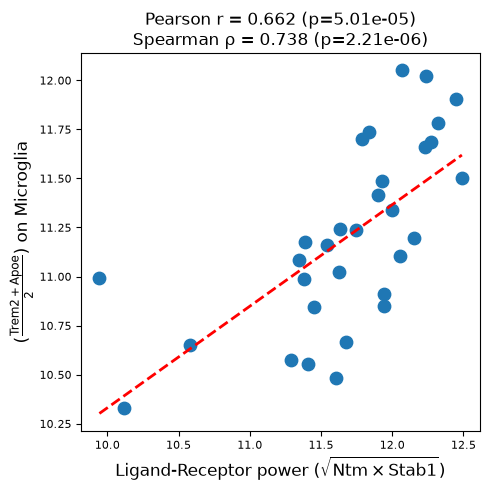

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

oligo = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/Oligodendrocyte_bulk_rna_vsd_preprocess.csv",
    index_col=0
)

micro = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/Microglia_bulk_rna_vsd_preprocess.csv",
    index_col=0
)

x = np.sqrt(oligo.loc["Ntm"] * micro.loc["Stab1"])
y = (micro.loc["Trem2"] + micro.loc["Apoe"]) / 2

df = pd.DataFrame({
    "Ligand_Receptor_power": x,
    "Trem2_Apoe_mean_expression": y
}).dropna()

pearson_r, pearson_p = pearsonr(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"]
)

spearman_rho, spearman_p = spearmanr(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"]
)

plt.figure(figsize=(5,5))

plt.scatter(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"],
    s=80
)

coef = np.polyfit(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"],
    1
)

x_line = np.linspace(
    df["Ligand_Receptor_power"].min(),
    df["Ligand_Receptor_power"].max(),
    100
)

y_line = coef[0] * x_line + coef[1]

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    color="red",
    linewidth=2
)

plt.xlabel(
    r"Ligand-Receptor power ($\sqrt{\mathrm{Ntm} \times \mathrm{Stab1}}$)",
    fontsize=12
)

plt.ylabel(
    r"($\frac{\mathrm{Trem2}+\mathrm{Apoe}}{2}$) on Microglia",
    fontsize=12
)
plt.tick_params(
    axis="both",
    labelsize=8
)

plt.title(
    f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e})\n"
    f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.2e})",
    fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")
adata = adata[adata.obs["mannual_annotaion"].isin(["Oligodendrocyte", "Microglia"])].copy()

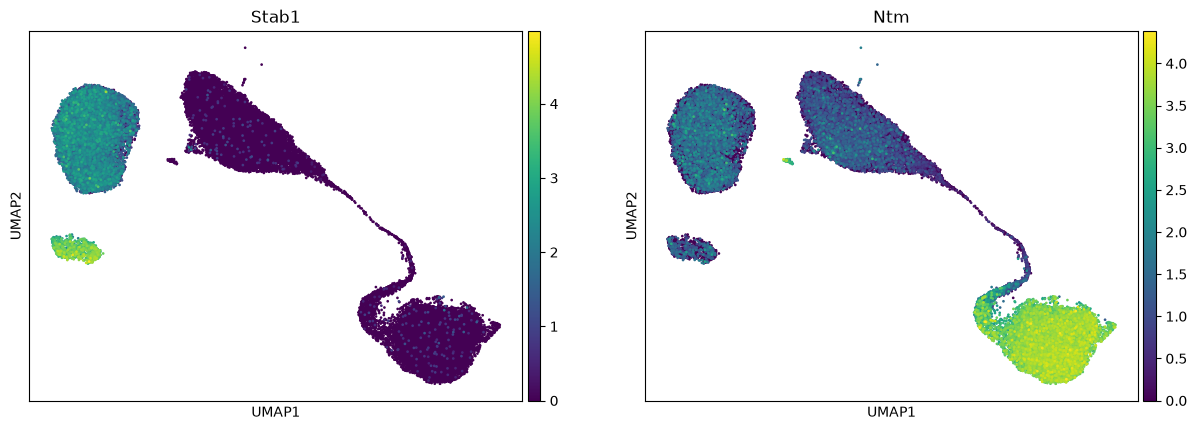

In [19]:
sc.pl.umap(
    adata,
    color=['Stab1','Ntm'],
    use_raw=False,
    legend_loc='on data',
    s=15
)

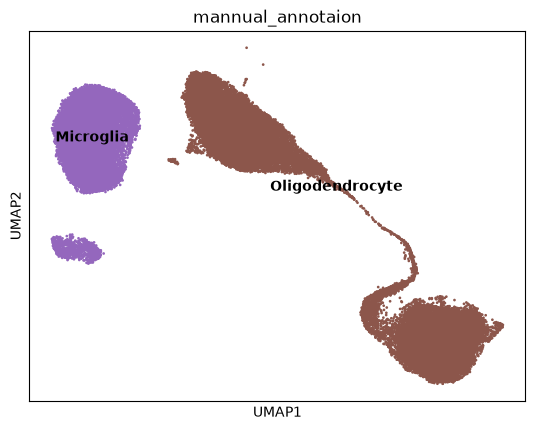

In [20]:
sc.pl.umap(
    adata,
    color=['mannual_annotaion'],
    use_raw=False,
    legend_loc='on data',
    s=15
)